# Feedforward Neural Dynamics

## Motivation

Single-neuron models are useful for understanding membrane dynamics, but neural systems are fundamentally networked. Even a very small feedforward network can demonstrate how spikes propagate between connected neurons through synaptic interactions.

This notebook introduces a simple two-neuron feedforward model and explores how presynaptic activity shapes postsynaptic responses.

## Feedforward Architecture

The simplest feedforward network contains a presynaptic neuron that sends activity to a postsynaptic neuron through a synaptic connection.

In this notebook, the architecture is:

$$
\text{Neuron 1} \rightarrow \text{Synapse} \rightarrow \text{Neuron 2}
$$

Neuron 1 provides spike times. These spikes generate synaptic currents, which are then injected into Neuron 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Time parameters
T = 200           # total simulation time (ms)
dt = 0.1          # time step (ms)
time = np.arange(0, T, dt)

## Presynaptic Spike Generation

For this feedforward example, presynaptic spikes are predefined rather than generated by a full neuron model. This makes it easier to focus on how spikes are transmitted through the synapse.

In [3]:
presynaptic_spike_times = [30, 60, 90, 120, 150]

presynaptic_spike_train = np.zeros_like(time)

for spike_time in presynaptic_spike_times:
    spike_index = int(spike_time / dt)
    presynaptic_spike_train[spike_index] = 1

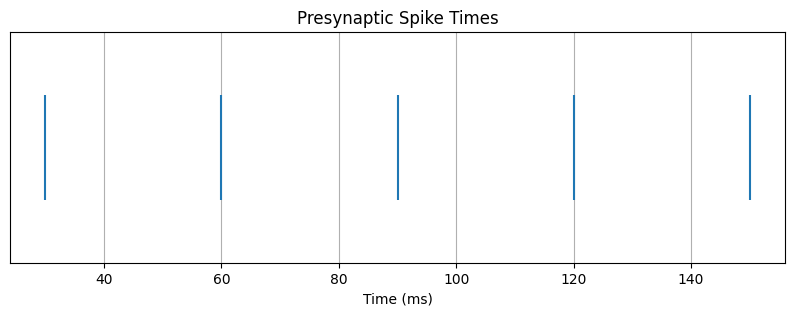

In [4]:
plt.figure(figsize=(10, 3))
plt.eventplot(presynaptic_spike_times, lineoffsets=1, linelengths=0.6)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Presynaptic Spike Times")
plt.grid(True)
plt.show()

## Synaptic Transmission Between Neurons

Each presynaptic spike produces a postsynaptic current. Here, synaptic transmission is modeled using an alpha-function current.

This is still a simplified phenomenological model: it captures the idea that synaptic input rises and decays over time, but it does not model detailed receptor kinetics or conductance-based synapses.

In [5]:
def alpha_current(time, spike_time, amplitude=1.0, tau_syn=10.0):
    """
    Compute an alpha-function synaptic current triggered by one presynaptic spike.
    """
    current = np.zeros_like(time)

    for i, t in enumerate(time):
        if t >= spike_time:
            time_since_spike = t - spike_time
            current[i] = amplitude * (time_since_spike / tau_syn) * np.exp(1 - time_since_spike / tau_syn)
    return current

In [6]:
synaptic_weight = 1.0
tau_syn = 10.0

synaptic_current = np.zeros_like(time)

for spike_time in presynaptic_spike_times:
    synaptic_current += alpha_current(
        time=time,
        spike_time=spike_time,
        amplitude=synaptic_weight,
        tau_syn=tau_syn
    )

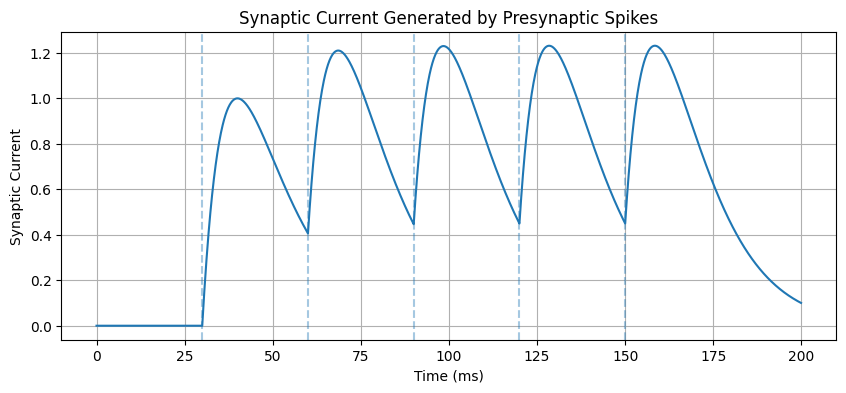

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(time, synaptic_current)

for spike_time in presynaptic_spike_times:
    plt.axvline(spike_time, linestyle="--", alpha=0.4)

plt.xlabel("Time (ms)")
plt.ylabel("Synaptic Current")
plt.title("Synaptic Current Generated by Presynaptic Spikes")
plt.grid(True)
plt.show()

## Postsynaptic Membrane Response

The synaptic current is now injected into a postsynaptic LIF neuron. This allows us to observe how presynaptic spike timing shapes the voltage dynamics of the downstream neuron.

In [8]:
# Postsynaptic LIF neuron parameters
V_rest = -70.0
V_reset = -65.0
V_th = -50.0
tau_m = 10.0
R = 8.0

postsynaptic_voltage = np.zeros_like(time)
postsynaptic_voltage[0] = V_rest
postsynaptic_spike_times = []

for i in range(1, len(time)):
    dV = dt / tau_m * (-(postsynaptic_voltage[i - 1] - V_rest) + R * synaptic_current[i - 1])
    postsynaptic_voltage[i] = postsynaptic_voltage[i - 1] + dV

    if postsynaptic_voltage[i] >= V_th:
        postsynaptic_spike_times.append(time[i])
        postsynaptic_voltage[i] = V_reset

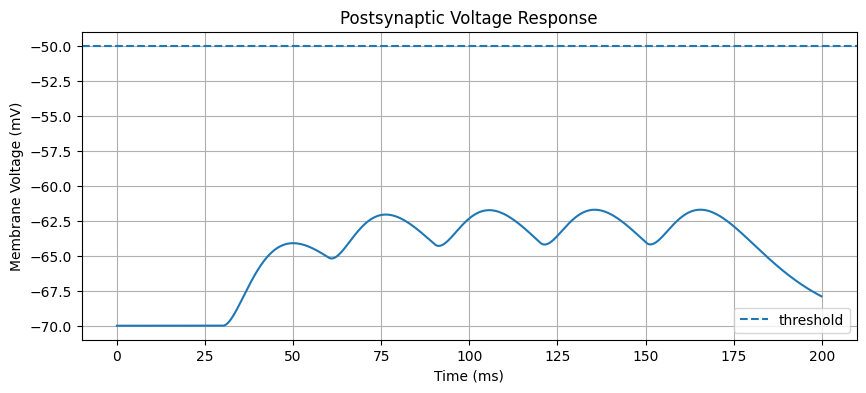

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(time, postsynaptic_voltage)
plt.axhline(V_th, linestyle="--", label="threshold")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("Postsynaptic Voltage Response")
plt.grid(True)
plt.legend()
plt.show()

The postsynaptic voltage changes in response to incoming synaptic current. Depending on the synaptic strength and timing of inputs, the postsynaptic neuron may remain subthreshold or emit spikes.

## Spike Propagation in a Two-Neuron System

We can summarize feedforward propagation by plotting presynaptic spike times, synaptic current, and postsynaptic voltage together. This makes the temporal relationship between input spikes and downstream membrane response easier to see.

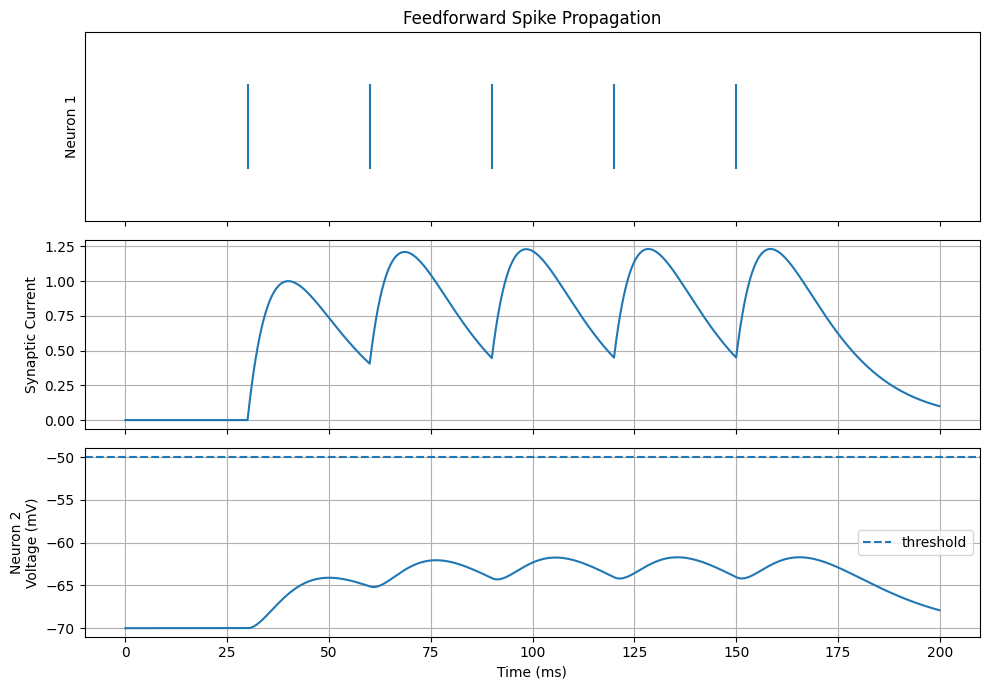

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].eventplot(presynaptic_spike_times, lineoffsets=1, linelengths=0.6)
axes[0].set_yticks([])
axes[0].set_ylabel("Neuron 1")
axes[0].set_title("Feedforward Spike Propagation")

axes[1].plot(time, synaptic_current)
axes[1].set_ylabel("Synaptic Current")
axes[1].grid(True)

axes[2].plot(time, postsynaptic_voltage)
axes[2].axhline(V_th, linestyle="--", label="threshold")
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel("Neuron 2\nVoltage (mV)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

This visualization shows how presynaptic spike timing is transformed into synaptic current and then into postsynaptic voltage dynamics. Even in a two-neuron system, the synaptic connection introduces a temporal transformation between input spikes and downstream neural response.

## Effect of Synaptic Strength

Synaptic strength determines how strongly presynaptic spikes influence the postsynaptic neuron. Larger weights produce larger synaptic currents and stronger postsynaptic voltage responses.

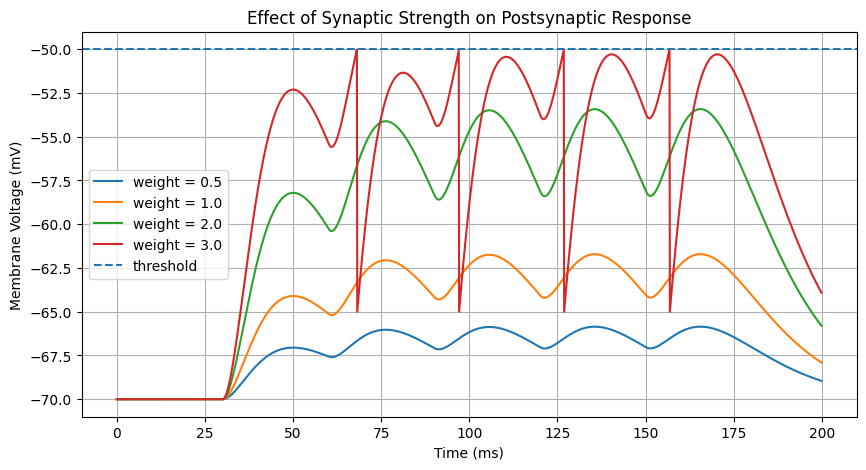

In [11]:
weights = [0.5, 1.0, 2.0, 3.0]

plt.figure(figsize=(10, 5))

for weight in weights:
    current_weighted = np.zeros_like(time)

    for spike_time in presynaptic_spike_times:
        current_weighted += alpha_current(
            time=time,
            spike_time=spike_time,
            amplitude=weight,
            tau_syn=tau_syn
        )

    voltage_weighted = np.zeros_like(time)
    voltage_weighted[0] = V_rest

    for i in range(1, len(time)):
        dV = dt / tau_m * (-(voltage_weighted[i - 1] - V_rest) + R * current_weighted[i - 1])
        voltage_weighted[i] = voltage_weighted[i - 1] + dV

        if voltage_weighted[i] >= V_th:
            voltage_weighted[i] = V_reset

    plt.plot(time, voltage_weighted, label=f"weight = {weight}")

plt.axhline(V_th, linestyle="--", label="threshold")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("Effect of Synaptic Strength on Postsynaptic Response")
plt.grid(True)
plt.legend()
plt.show()

Increasing synaptic strength changes the downstream voltage response and can determine whether the postsynaptic neuron remains subthreshold or reaches spike threshold. This provides the basic foundation for later plasticity models, where synaptic weights change over time.

## Limitations

This model is intentionally simplified. The presynaptic neuron is not simulated as a full LIF neuron; instead, its spike times are predefined. The synapse is modeled with a phenomenological alpha-function current rather than detailed conductance-based receptor dynamics. The network also contains only two neurons and does not include inhibition, recurrent connections, or biological variability.

These simplifications are useful at this stage because they make the causal chain clear: presynaptic spikes generate synaptic current, and synaptic current shapes postsynaptic voltage.

## Connection to Plasticity Models

The next step is to allow synaptic strength to change over time. In biological neural systems, synaptic weights are not fixed; they can be modified by activity-dependent mechanisms.

This leads naturally to models of synaptic plasticity, including short-term synaptic dynamics and spike-timing dependent plasticity (STDP), where the timing of pre- and postsynaptic spikes influences how synaptic weights change.